In [1]:
import re
from pathlib import Path

import numpy as np
import meshio
import matplotlib.pyplot as plt

In [2]:
# Paths — adjust BASE if running the notebook from a different working directory
BASE        = Path(".")
DATA_DIR    = BASE / "w7x_coil_0_data"     # coilforce VTU outputs
PETSC_DIR   = BASE / "w7x_coil_0_data_petsc"     # coilforce VTU outputs
DOLFINX_DIR = BASE / "w7x_coil_0_dolfinx"  # dolfinx validation VTU outputs

COIL_ID = 0  # index of the base coil to load (coil_00_*)

In [3]:
def discover_n_values(data_dir: Path, dolfinx_dir: Path, coil_id: int) -> list[int]:
    """Return sorted list of n values that have all three required VTU files.

    A valid n value must have:
      data_dir/n_<n>/coil_<id>_run.vtu
      dolfinx_dir/n_<n>/runA_volumetric_BS/coil_<id>_run_dolfinx.vtu
      dolfinx_dir/n_<n>/runB_coilfem_B/coil_<id>_run_dolfinx.vtu
    """
    pat = re.compile(r"^n_(\d+)$")
    prefix = f"coil_{coil_id:02d}"

    valid = []
    for subdir in sorted(data_dir.iterdir()):
        m = pat.match(subdir.name)
        if not m:
            continue
        n = int(m.group(1))

        cf_vtu   = data_dir    / f"n_{n}" / f"{prefix}_run.vtu"
        dfxA_vtu = dolfinx_dir / f"n_{n}" / "runA_volumetric_BS" / f"{prefix}_run_dolfinx.vtu"
        dfxB_vtu = dolfinx_dir / f"n_{n}" / "runB_coilfem_B"     / f"{prefix}_run_dolfinx.vtu"

        if cf_vtu.exists() and dfxA_vtu.exists() and dfxB_vtu.exists():
            valid.append(n)

    return sorted(valid)


n_values = discover_n_values(DATA_DIR, DOLFINX_DIR, COIL_ID)
print(f"Found {len(n_values)} complete n values: {n_values}")

Found 8 complete n values: [100, 125, 150, 175, 200, 225, 250, 275]


In [4]:
def load_vtu(path: Path) -> tuple[dict, dict]:
    """Read a coilforce / dolfinx VTU file and return (node_dict, cell_dict).

    node_dict  — point-data arrays keyed by field name, e.g.:
        'displacement_m'  : (n_nodes, 3) [m]
        'support_weights' : (n_nodes,)
        'spring_k_Npm3'   : (n_nodes,) [N/m^3]

    cell_dict  — cell-data arrays (one value per element), e.g.:
        'von_mises_MPa'   : (n_cells,) [MPa]
        'f_vol_Npm3'      : (n_cells, 3) [N/m^3]
        'B_self_T'        : (n_cells, 3) [T]
        'B_ext_T'         : (n_cells, 3) [T]

    meshio wraps each cell-data array in an extra list (one per cell block);
    we unwrap the first (and only) block here.
    """
    mesh = meshio.read(str(path))
    node_dict = dict(mesh.point_data)
    cell_dict = {k: v[0] for k, v in mesh.cell_data.items()}
    # --- geometry for volume-weighted reductions (tet corner volumes) ---
    # First 4 nodes are the tet corners for both 'tetra' and 'tetra10' blocks.
    conn4 = mesh.cells[0].data[:, :4]
    p = mesh.points[conn4]                       # (n_cells, 4, 3)
    vol = np.abs(np.einsum(
        "ci,ci->c",
        np.cross(p[:, 1] - p[:, 0], p[:, 2] - p[:, 0]),
        p[:, 3] - p[:, 0],
    )) / 6.0
    cell_dict["conn"]   = conn4
    cell_dict["volume"] = vol
    return node_dict, cell_dict

In [5]:
# --- Node-level lists (point data: displacement, support weights, ...) ---
cf_nodes       = []   # CoilFEM            — w7x_coil_0_data
cf_petsc_nodes = []   # CoilFEM            — w7x_coil_0_data
dfx_A_nodes    = []   # DolfinX Run A      — runA_volumetric_BS (independent B-field)
dfx_B_nodes    = []   # DolfinX Run B      — runB_coilfem_B     (coilforce B-field, elasticity-only)

# --- Cell-centre lists (cell data: von Mises, body force, B fields, ...) ---
cf_cells       = []
cf_petsc_cells = []
dfx_A_cells    = []
dfx_B_cells    = []

# --- Timing lists (runtime from timings.npz) ---
# CoilFEM (JAX-FEM) timings include t_jit (compile) and t_run (solve);
# DolfinX timings include t_run only.
cf_timings       = []   # CoilFEM / JAX-FEM
cf_petsc_timings = []   # CoilFEM / JAX-FEM
dfx_A_timings    = []   # DolfinX Run A
dfx_B_timings    = []   # DolfinX Run B


def load_timings(path):
    """Read a timings.npz file and return a dict of scalar runtimes (seconds).

    Always exposes 't_run'; CoilFEM/JAX-FEM files additionally expose 't_jit'.
    Returns NaN for any missing/unreadable timing.
    """
    out = {"t_jit": float("nan"), "t_run": float("nan")}
    if path.exists():
        with np.load(path, allow_pickle=True) as data:
            for key in ("t_jit", "t_run"):
                if key in data.files:
                    out[key] = float(data[key])
    return out


prefix = f"coil_{COIL_ID:02d}"

for n in n_values:
    cf_vtu       = DATA_DIR    / f"n_{n}" / f"{prefix}_run.vtu"
    cf_petsc_vtu = PETSC_DIR   / f"n_{n}" / f"{prefix}_run.vtu"
    dfxA_vtu     = DOLFINX_DIR / f"n_{n}" / "runA_volumetric_BS" / f"{prefix}_run_dolfinx.vtu"
    dfxB_vtu     = DOLFINX_DIR / f"n_{n}" / "runB_coilfem_B"     / f"{prefix}_run_dolfinx.vtu"

    cf_npz       = DATA_DIR    / f"n_{n}" / "timings.npz"
    cf_petsc_npz = PETSC_DIR   / f"n_{n}" / "timings.npz"
    dfxA_npz     = DOLFINX_DIR / f"n_{n}" / "runA_volumetric_BS" / "timings.npz"
    dfxB_npz     = DOLFINX_DIR / f"n_{n}" / "runB_coilfem_B"     / "timings.npz"

    nd, cd = load_vtu(cf_vtu)
    cf_nodes.append({"n": n, **nd})
    cf_cells.append({"n": n, **cd})
    cf_timings.append({"n": n, **load_timings(cf_npz)})

    nd, cd = load_vtu(cf_petsc_vtu)
    cf_petsc_nodes.append({"n": n, **nd})
    cf_petsc_cells.append({"n": n, **cd})
    cf_petsc_timings.append({"n": n, **load_timings(cf_petsc_npz)})

    nd, cd = load_vtu(dfxA_vtu)
    dfx_A_nodes.append({"n": n, **nd})
    dfx_A_cells.append({"n": n, **cd})
    dfx_A_timings.append({"n": n, **load_timings(dfxA_npz)})

    nd, cd = load_vtu(dfxB_vtu)
    dfx_B_nodes.append({"n": n, **nd})
    dfx_B_cells.append({"n": n, **cd})
    dfx_B_timings.append({"n": n, **load_timings(dfxB_npz)})

print(f"Loaded {len(cf_nodes)} configurations.")
print(f"Node-level fields  (CoilFEM example): {[k for k in cf_nodes[0] if k != 'n']}")
print(f"Cell-centre fields (CoilFEM example): {[k for k in cf_cells[0] if k not in ('n', 'conn', 'volume')]}")
print(f"Timing fields      (CoilFEM example): {[k for k in cf_timings[0] if k != 'n']}")

Loaded 8 configurations.
Node-level fields  (CoilFEM example): ['displacement_m', 'support_weights', 'spring_k_Npm3']
Cell-centre fields (CoilFEM example): ['von_mises_MPa', 'von_mises_thermal_MPa', 'von_mises_elastic_MPa', 'f_vol_Npm3', 'B_self_T', 'B_ext_T']
Timing fields      (CoilFEM example): ['t_jit', 't_run']


In [6]:
# Calculating cell numbers
n_cells = [c['von_mises_MPa'].size for c in dfx_A_cells]

In [7]:
len(cf_nodes)

8

In [8]:
max_err_displacement_A = []
max_err_displacement_B = []
max_err_von_mises_A = []
max_err_von_mises_B = []
min_err_displacement_A = []
min_err_displacement_B = []
min_err_von_mises_A = []
min_err_von_mises_B = []
med_err_displacement_A = []
med_err_displacement_B = []
med_err_von_mises_A = []
med_err_von_mises_B = []
ns = []
for i in range(len(dfx_A_nodes)):
    avg_displacement = np.average(np.abs(cf_nodes[i]['displacement_m']))
    avg_von_mises = np.average(np.abs(cf_cells[i]['von_mises_MPa']))
    err_displacement_A = np.abs(cf_nodes[i]['displacement_m'] - dfx_A_nodes[i]['displacement_m'])/avg_displacement
    err_displacement_B = np.abs(cf_nodes[i]['displacement_m'] - dfx_B_nodes[i]['displacement_m'])/avg_displacement
    err_von_mises_A = np.abs(cf_cells[i]['von_mises_MPa'] - dfx_A_cells[i]['von_mises_MPa'])/avg_von_mises
    err_von_mises_B = np.abs(cf_cells[i]['von_mises_MPa'] - dfx_B_cells[i]['von_mises_MPa'])/avg_von_mises
    max_err_displacement_A.append(np.max(err_displacement_A))
    max_err_displacement_B.append(np.max(err_displacement_B))
    max_err_von_mises_A.append(np.max(err_von_mises_A))
    max_err_von_mises_B.append(np.max(err_von_mises_B))
    min_err_displacement_A.append(np.min(err_displacement_A))
    min_err_displacement_B.append(np.min(err_displacement_B))
    min_err_von_mises_A.append(np.min(err_von_mises_A))
    min_err_von_mises_B.append(np.min(err_von_mises_B))
    med_err_displacement_A.append(np.median(err_displacement_A))
    med_err_displacement_B.append(np.median(err_displacement_B))
    med_err_von_mises_A.append(np.median(err_von_mises_A))
    med_err_von_mises_B.append(np.median(err_von_mises_B))
    ns.append(cf_cells[i]['n'])
max_err_displacement_A = np.array(max_err_displacement_A)
max_err_displacement_B = np.array(max_err_displacement_B)
max_err_von_mises_A = np.array(max_err_von_mises_A)
max_err_von_mises_B = np.array(max_err_von_mises_B)
min_err_displacement_A = np.array(min_err_displacement_A)
min_err_displacement_B = np.array(min_err_displacement_B)
min_err_von_mises_A = np.array(min_err_von_mises_A)
min_err_von_mises_B = np.array(min_err_von_mises_B)
med_err_displacement_A = np.array(med_err_displacement_A)
med_err_displacement_B = np.array(med_err_displacement_B)
med_err_von_mises_A = np.array(med_err_von_mises_A)
med_err_von_mises_B = np.array(med_err_von_mises_B)

Max error 1: Von mises - 0.021836550907203153 displacement - 0.028195974926953523
Max error 2: Von mises - 7.803232771919215e-11 displacement - 1.257551169964463e-10


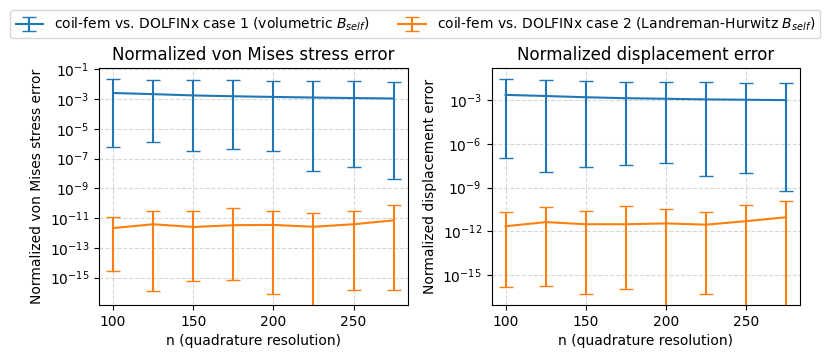

In [9]:
print('Max error 1: Von mises -', np.max(max_err_von_mises_A), 'displacement -', np.max(max_err_displacement_A))
print('Max error 2: Von mises -', np.max(max_err_von_mises_B), 'displacement -', np.max(max_err_displacement_B))
labels = [
    "coil-fem vs. DOLFINx case 1 (volumetric $B_{self}$)",
    "coil-fem vs. DOLFINx case 2 (Landreman-Hurwitz $B_{self}$)",
]
fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
axs[0].errorbar(ns, med_err_von_mises_A, (med_err_von_mises_A-min_err_von_mises_A, max_err_von_mises_A-med_err_von_mises_A), label=labels[0], capsize=5)
axs[0].errorbar(ns, med_err_von_mises_B, (med_err_von_mises_B-min_err_von_mises_B, max_err_von_mises_B-med_err_von_mises_B), label=labels[1], capsize=5)
axs[0].set_xlabel("n (quadrature resolution)")
axs[0].set_ylabel("Normalized von Mises stress error")
axs[0].set_yscale("log")
axs[0].set_title("Normalized von Mises stress error")
axs[0].grid(True, linestyle="--", alpha=0.5)
axs[1].errorbar(ns, med_err_displacement_A, (med_err_displacement_A-min_err_displacement_A, max_err_displacement_A-med_err_displacement_A), label=labels[0], capsize=5)
axs[1].errorbar(ns, med_err_displacement_B, (med_err_displacement_B-min_err_displacement_B, max_err_displacement_B-med_err_displacement_B), label=labels[1], capsize=5)
axs[1].set_xlabel("n (quadrature resolution)")
axs[1].set_ylabel("Normalized displacement error")
axs[1].set_title("Normalized displacement error")
axs[1].set_yscale("log")
axs[1].grid(True, linestyle="--", alpha=0.5)

handles, lgd_labels = axs[0].get_legend_handles_labels()
fig.legend(handles, lgd_labels, loc="upper center",
           ncol=len(lgd_labels), bbox_to_anchor=(0.5, 0.9))
fig.tight_layout(rect=[0, 0, 1, 0.83])   # reserve top ~17% for the legend
plt.savefig('../figures/bench-error.pdf', bbox_inches='tight')
plt.show()

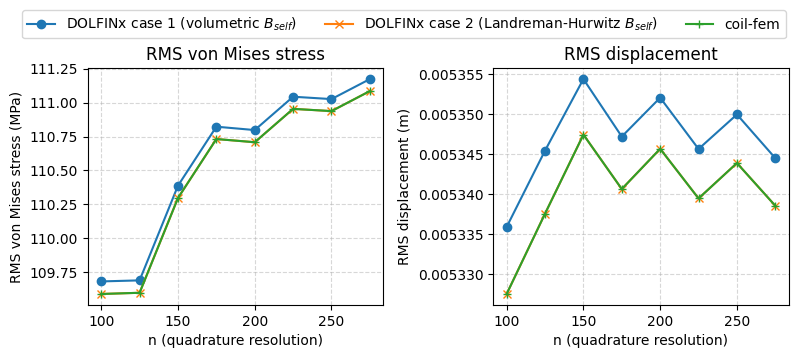

In [10]:
labels = [
    "DOLFINx case 1 (volumetric $B_{self}$)",
    "DOLFINx case 2 (Landreman-Hurwitz $B_{self}$)",
    "coil-fem",
]
cells = [dfx_A_cells, dfx_B_cells, cf_cells]
nodes = [dfx_A_nodes, dfx_B_nodes, cf_nodes]   # <-- reordered, see note below
markers = ['o', 'x', '+']

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
for i in range(len(labels)):
    label, cell = labels[i], cells[i]
    ns  = [d["n"] for d in cell]
    # von Mises is one value per cell -> volume-weighted RMS = sqrt(sum(vm^2 V)/sum(V))
    vms = [np.sqrt(np.sum(d["von_mises_MPa"]**2 * d["volume"]) / np.sum(d["volume"]))
           for d in cell]
    axs[0].plot(ns, vms, marker=markers[i], label=label)
axs[0].set_xlabel("n (quadrature resolution)")
axs[0].set_ylabel("RMS von Mises stress (MPa)")
axs[0].set_title("RMS von Mises stress")
axs[0].grid(True, linestyle="--", alpha=0.5)

for i in range(len(labels)):
    label, node, cell = labels[i], nodes[i], cells[i]
    ns  = [d["n"] for d in node]
    # |u| is a nodal field; average |u|^2 over each cell's corner nodes, then
    # volume-weight: sqrt(sum(<|u|^2>_cell V)/sum(V)).
    rms = []
    for nd, cd in zip(node, cell):
        dmag      = np.linalg.norm(nd["displacement_m"], axis=-1)   # (n_nodes,)
        cell_mean = (dmag[cd["conn"]]**2).mean(axis=1)              # (n_cells,)
        rms.append(np.sqrt(np.sum(cell_mean * cd["volume"]) / np.sum(cd["volume"])))
    axs[1].plot(ns, rms, marker=markers[i], label=label)
axs[1].set_xlabel("n (quadrature resolution)")
axs[1].set_ylabel("RMS displacement (m)")
axs[1].set_title("RMS displacement")
axs[1].grid(True, linestyle="--", alpha=0.5)

handles, lgd_labels = axs[0].get_legend_handles_labels()
fig.legend(handles, lgd_labels, loc="upper center",
           ncol=len(lgd_labels), bbox_to_anchor=(0.5, 0.9))
fig.tight_layout(rect=[0, 0, 1, 0.83])
plt.savefig('../figures/bench-conv.pdf', bbox_inches='tight')
plt.show()

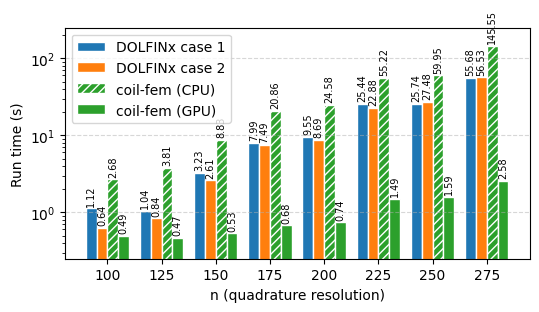

In [11]:
# Grouped bar version of the timing plot (same data as above)
labels = [
    "DOLFINx case 1",
    "DOLFINx case 2",
    "coil-fem (CPU)",
    "coil-fem (GPU)",
]
times = [
    [t['t_run'] for t in dfx_A_timings],
    [t['t_run'] for t in dfx_B_timings],
    [t['t_run'] for t in cf_petsc_timings],
    [t['t_run'] for t in cf_timings],
]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:green']
hatches = [None, None, '////', None]
ns = [d["n"] for d in cf_timings]

x = np.arange(len(ns))            # one group per n value
width = 0.8 / len(labels)         # bar width within a group

plt.figure(figsize=(6, 3))
for i, label in enumerate(labels):
    offset = (i - (len(labels) - 1) / 2) * width
    bars = plt.bar(x + offset, times[i], width, label=label,
                   color=colors[i], hatch=hatches[i], edgecolor='white')
    plt.bar_label(bars, fmt="%.2f", padding=2, fontsize=7, rotation=90)

plt.xticks(x, ns)
plt.xlabel("n (quadrature resolution)")
plt.ylabel("Run time (s)")
plt.yscale('log')
plt.ylim(0.25, 250)
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.legend()
plt.savefig('../figures/bench-time-bar.pdf', bbox_inches='tight')
plt.show()